# Two-Stage LTV Model & Zero-Hack

Двухэтапная модель для zero-inflated LTV:
- **Stage 1 (Classifier):** P(gmv > 0)
- **Stage 2 (Regressor):** E[gmv | gmv > 0]

⚠️ **СТАТУС: ОПАСНО ДЛЯ ЛИДЕРБОРДА**
Метод принудительного зануления предсказаний (Zero-Hack), основанный на классификаторе из Stage 1, локально улучшал скор, но на публичном лидерборде привел к катастрофическому падению (1.73573). 
Метрика RMSLE слишком жестко штрафует за жесткие нули. Метод исключен из финального пайплайна.

In [2]:
import polars as pl
import pandas as pd
import numpy as np
import json
from pathlib import Path
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

FEATURES_DIR = Path("../data/processed/features_v3")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS = 4
TOP_N_FEATURES = 150

def rmsle_score(y_true, y_pred):
    y_pred_clipped = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

def gini_normalized(y_true, y_pred):
    def _gini(actual, predicted):
        n = len(actual)
        indices = np.argsort(-predicted)
        sorted_actual = actual[indices]
        cumulative = np.cumsum(sorted_actual)
        gini_sum = cumulative.sum() / (sorted_actual.sum() + 1e-9) - (n + 1) / 2
        return gini_sum / n
    return _gini(y_true, y_pred) / (_gini(y_true, y_true) + 1e-9)

def load_fold(fold_path: Path) -> pd.DataFrame:
    return pl.read_parquet(fold_path / "batch_*.parquet").to_pandas()

print("Загрузка данных...")
all_folds = []
for fold_idx in range(N_FOLDS):
    fold_df = load_fold(FEATURES_DIR / f"fold_{fold_idx:02d}")
    all_folds.append(fold_df)
    n_buyers = (fold_df["target"] > 0).sum()
    print(f"  Фолд {fold_idx}: {len(fold_df):,} записей | buyers={n_buyers:,} ({n_buyers/len(fold_df)*100:.1f}%)")

test_df = load_fold(FEATURES_DIR / "fold_test")
print(f"  Test: {len(test_df):,} записей")

Загрузка данных...
  Фолд 0: 250,000 записей | buyers=132,441 (53.0%)
  Фолд 1: 250,000 записей | buyers=140,671 (56.3%)
  Фолд 2: 250,000 записей | buyers=140,770 (56.3%)
  Фолд 3: 250,000 записей | buyers=135,165 (54.1%)
  Test: 250,000 записей


## Feature Selection

In [3]:
imp_paths = [
    Path("../data/processed/feature_importance_v3.json"),
    Path("../data/processed/feature_importance_v2.json"),
]
ranked_features = None
for imp_path in imp_paths:
    if imp_path.exists():
        with open(imp_path) as f:
            imp_data = json.load(f)
        ranked_features = [item["name"] for item in imp_data["features_ranked"]]
        print(f"Загружено из: {imp_path.name} ({len(ranked_features)} фичей)")
        break

drop_cols = ["user_id", "anchor_date", "target"]
all_features = [c for c in test_df.columns if c not in drop_cols]

if ranked_features:
    features = [f for f in ranked_features if f in all_features][:TOP_N_FEATURES]
else:
    features = all_features

print(f"Фичей для обучения: {len(features)}")

fold_df_all = pd.concat(all_folds)
n_total = len(fold_df_all)
n_zeros = (fold_df_all["target"] == 0).sum()
n_buyers = n_total - n_zeros
print(f"\nАнализ target (все фолды):")
print(f"  Нули (target=0): {n_zeros:,} ({n_zeros/n_total*100:.1f}%)")
print(f"  Покупатели:      {n_buyers:,} ({n_buyers/n_total*100:.1f}%)")
print(f"  Среди покупателей: mean={fold_df_all[fold_df_all['target']>0]['target'].mean():.1f}")

Загружено из: feature_importance_v3.json (440 фичей)
Фичей для обучения: 150

Анализ target (все фолды):
  Нули (target=0): 450,953 (45.1%)
  Покупатели:      549,047 (54.9%)
  Среди покупателей: mean=172.7


## Stage 1: Классификатор (купит / не купит)

Предсказывает вероятность P(gmv > 0).

In [4]:
clf_params = {
    'iterations': 3000,
    'learning_rate': 0.05,
    'depth': 7,
    'l2_leaf_reg': 3.0,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'GPU',
    'devices': '0',
    'random_seed': 42,
    'early_stopping_rounds': 100,
    'verbose': 500,
}

clf_fold_scores = []
clf_test_probs = np.zeros(len(test_df))
clf_models = []

print("=== Stage 1: Classifier ===")
for val_idx in range(1, N_FOLDS):
    train_df = pd.concat([all_folds[i] for i in range(val_idx)], ignore_index=True)
    val_df = all_folds[val_idx]

    y_train_bin = (train_df["target"] > 0).astype(int)
    y_val_bin = (val_df["target"] > 0).astype(int)

    train_str = "+".join(str(i) for i in range(val_idx))
    print(f"\n--- Train: [{train_str}] ({len(train_df):,}) | Val: {val_idx} ({len(val_df):,}) ---")
    print(f"  Train buyers: {y_train_bin.sum():,} ({y_train_bin.mean()*100:.1f}%)")
    print(f"  Val buyers:   {y_val_bin.sum():,} ({y_val_bin.mean()*100:.1f}%)")

    train_pool = Pool(train_df[features], y_train_bin)
    val_pool = Pool(val_df[features], y_val_bin)

    clf = CatBoostClassifier(**clf_params)
    clf.fit(train_pool, eval_set=val_pool)
    clf_models.append(clf)

    val_probs = clf.predict_proba(val_df[features])[:, 1]
    auc = roc_auc_score(y_val_bin, val_probs)
    ap = average_precision_score(y_val_bin, val_probs)
    clf_fold_scores.append(auc)

    print(f"  AUC={auc:.4f} | AP={ap:.4f}")

    test_probs = clf.predict_proba(test_df[features])[:, 1]
    clf_test_probs += test_probs / (N_FOLDS - 1)

    clf.save_model(str(MODELS_DIR / f"clf_v1_fold_{val_idx}.cbm"))

print(f"\nMean AUC: {np.mean(clf_fold_scores):.4f} ± {np.std(clf_fold_scores):.4f}")

=== Stage 1: Classifier ===

--- Train: [0] (250,000) | Val: 1 (250,000) ---
  Train buyers: 132,441 (53.0%)
  Val buyers:   140,671 (56.3%)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8390360	best: 0.8390360 (0)	total: 200ms	remaining: 10m
bestTest = 0.8471057117
bestIteration = 296
Shrink model to first 297 iterations.
  AUC=0.8471 | AP=0.8837

--- Train: [0+1] (500,000) | Val: 2 (250,000) ---
  Train buyers: 273,112 (54.6%)
  Val buyers:   140,770 (56.3%)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8389688	best: 0.8389688 (0)	total: 60.4ms	remaining: 3m 1s
500:	test: 0.8477301	best: 0.8477511 (409)	total: 9.42s	remaining: 47s
bestTest = 0.8477511406
bestIteration = 409
Shrink model to first 410 iterations.
  AUC=0.8478 | AP=0.8823

--- Train: [0+1+2] (750,000) | Val: 3 (250,000) ---
  Train buyers: 413,882 (55.2%)
  Val buyers:   135,165 (54.1%)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8430463	best: 0.8430463 (0)	total: 30.2ms	remaining: 1m 30s
500:	test: 0.8526972	best: 0.8527010 (494)	total: 11s	remaining: 54.7s
bestTest = 0.8527013063
bestIteration = 543
Shrink model to first 544 iterations.
  AUC=0.8527 | AP=0.8768

Mean AUC: 0.8492 ± 0.0025


## Stage 2: Регрессор (E[gmv | gmv > 0])

Обучается **только на покупателях** (target > 0).

In [5]:
reg_params = {
    'iterations': 3000,
    'learning_rate': 0.05,
    'depth': 7,
    'l2_leaf_reg': 3.0,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'task_type': 'GPU',
    'devices': '0',
    'random_seed': 42,
    'early_stopping_rounds': 100,
    'verbose': 500,
}

reg_fold_scores = []
reg_test_preds = np.zeros(len(test_df))
reg_models = []

print("=== Stage 2: Regressor (только покупатели) ===")
for val_idx in range(1, N_FOLDS):
    train_df = pd.concat([all_folds[i] for i in range(val_idx)], ignore_index=True)
    val_df = all_folds[val_idx]

    train_buyers = train_df[train_df["target"] > 0]
    val_all = val_df

    y_train_log = np.log1p(train_buyers["target"].values)
    y_val = val_all["target"].values

    train_str = "+".join(str(i) for i in range(val_idx))
    print(f"\n--- Train: [{train_str}] покупатели={len(train_buyers):,} | Val all={len(val_all):,} ---")

    train_pool = Pool(train_buyers[features], y_train_log)
    val_pool_buyers = None

    reg = CatBoostRegressor(**reg_params)
    reg.fit(train_pool)
    reg_models.append(reg)

    val_reg_pred = np.expm1(np.clip(reg.predict(val_all[features]), 0, None))

    val_clf_probs = clf_models[val_idx - 1].predict_proba(val_all[features])[:, 1]
    val_final = val_clf_probs * val_reg_pred

    score = rmsle_score(y_val, val_final)
    gini = gini_normalized(y_val, val_final)
    reg_fold_scores.append(score)
    print(f"  Two-stage RMSLE: {score:.5f} | Gini: {gini:.4f}")

    test_reg_pred = np.expm1(np.clip(reg.predict(test_df[features]), 0, None))
    reg_test_preds += test_reg_pred / (N_FOLDS - 1)

    reg.save_model(str(MODELS_DIR / f"reg_v1_fold_{val_idx}.cbm"))

print(f"\nMean Two-Stage RMSLE: {np.mean(reg_fold_scores):.5f} ± {np.std(reg_fold_scores):.5f}")

=== Stage 2: Regressor (только покупатели) ===

--- Train: [0] покупатели=132,441 | Val all=250,000 ---
0:	learn: 1.3230238	total: 32.9ms	remaining: 1m 38s
500:	learn: 1.0964597	total: 4.11s	remaining: 20.5s
1000:	learn: 1.0670662	total: 7.7s	remaining: 15.4s
1500:	learn: 1.0399290	total: 10.9s	remaining: 10.9s
2000:	learn: 1.0147065	total: 14.7s	remaining: 7.36s
2500:	learn: 0.9907071	total: 18.5s	remaining: 3.68s
2999:	learn: 0.9677412	total: 21.9s	remaining: 0us
  Two-stage RMSLE: 1.97943 | Gini: 0.7282

--- Train: [0+1] покупатели=273,112 | Val all=250,000 ---
0:	learn: 1.3250186	total: 11.5ms	remaining: 34.4s
500:	learn: 1.1063529	total: 4.75s	remaining: 23.7s
1000:	learn: 1.0903445	total: 9.03s	remaining: 18s
1500:	learn: 1.0756711	total: 13.3s	remaining: 13.3s
2000:	learn: 1.0619232	total: 17.8s	remaining: 8.89s
2500:	learn: 1.0487243	total: 22.2s	remaining: 4.43s
2999:	learn: 1.0359246	total: 27.1s	remaining: 0us
  Two-stage RMSLE: 2.03363 | Gini: 0.7263

--- Train: [0+1+2] пок

## Финальный сабмит

predict = P(buy) × E[gmv | buy]

Two-Stage предсказания:
  P(buy): mean=0.5780 | min=0.0414 | max=0.9973
  E[gmv|buy]: mean=76.16 | median=43.80
  Final: mean=58.55 | median=25.05

Сохранено: ..\data\processed\two_stage_submission.csv
  blend alpha=0.3: mean=47.57 → ts_blend_ts30_cb70.csv
  blend alpha=0.4: mean=49.14 → ts_blend_ts40_cb60.csv
  blend alpha=0.5: mean=50.71 → ts_blend_ts50_cb50.csv
  blend alpha=0.6: mean=52.28 → ts_blend_ts60_cb40.csv
  blend alpha=0.7: mean=53.85 → ts_blend_ts70_cb30.csv


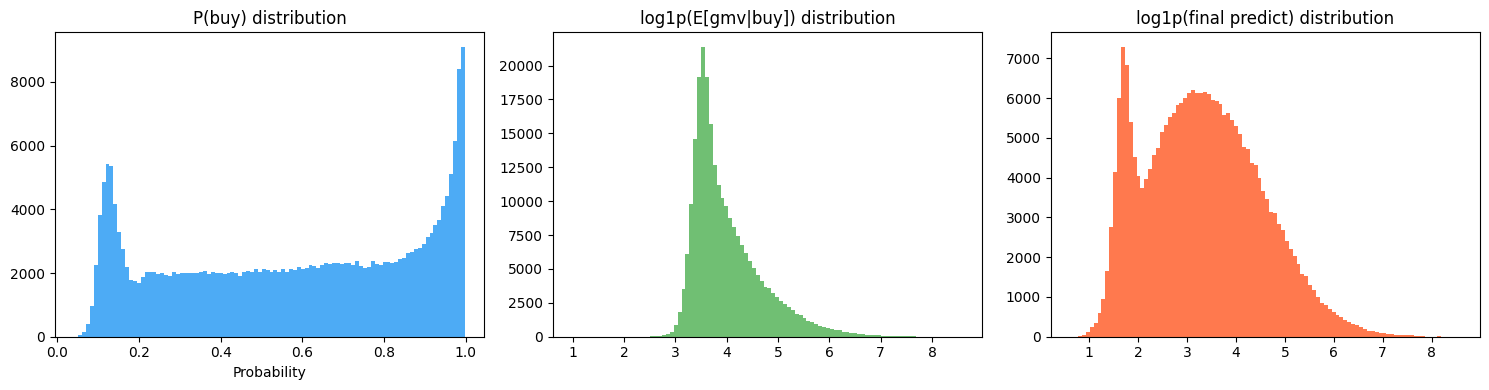

In [6]:
final_preds = clf_test_probs * reg_test_preds
final_preds = np.clip(final_preds, 0, None)

print("Two-Stage предсказания:")
print(f"  P(buy): mean={clf_test_probs.mean():.4f} | min={clf_test_probs.min():.4f} | max={clf_test_probs.max():.4f}")
print(f"  E[gmv|buy]: mean={reg_test_preds.mean():.2f} | median={np.median(reg_test_preds):.2f}")
print(f"  Final: mean={final_preds.mean():.2f} | median={np.median(final_preds):.2f}")

submit_df = pd.DataFrame({"user_id": test_df["user_id"], "predict": final_preds})
submit_path = Path("../data/processed/two_stage_submission.csv")
submit_df.to_csv(submit_path, index=False)
print(f"\nСохранено: {submit_path}")

cb_v3 = pd.read_csv(Path("../data/processed/catboost_v3_submission.csv"))
for alpha in [0.3, 0.4, 0.5, 0.6, 0.7]:
    blend = (alpha * final_preds + (1 - alpha) * cb_v3["predict"].values).clip(min=0)
    fname = f"ts_blend_ts{int(alpha*100)}_cb{int((1-alpha)*100)}.csv"
    pd.DataFrame({"user_id": test_df["user_id"], "predict": blend}).to_csv(
        Path("../data/processed") / fname, index=False)
    print(f"  blend alpha={alpha:.1f}: mean={blend.mean():.2f} → {fname}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(clf_test_probs, bins=100, color='#2196F3', alpha=0.8)
axes[0].set_title('P(buy) distribution')
axes[0].set_xlabel('Probability')

axes[1].hist(np.log1p(reg_test_preds), bins=100, color='#4CAF50', alpha=0.8)
axes[1].set_title('log1p(E[gmv|buy]) distribution')

axes[2].hist(np.log1p(final_preds), bins=100, color='#FF5722', alpha=0.8)
axes[2].set_title('log1p(final predict) distribution')

plt.tight_layout()
plt.show()

## Calibration порога P(buy)

Важно: у двухэтапной модели есть параметр — порог вероятности покупки.
Пользователям с P(buy) < threshold ставим 0 явно, что улучшает RMSLE.

In [7]:
print("Оптимизация порога P(buy) на последнем валидационном фолде...")

val_df_last = all_folds[-1]
y_val = val_df_last["target"].values

val_probs = clf_models[-1].predict_proba(val_df_last[features])[:, 1]
val_reg = np.expm1(np.clip(reg_models[-1].predict(val_df_last[features]), 0, None))
val_base = val_probs * val_reg

print(f"  Baseline two-stage RMSLE (no threshold): {rmsle_score(y_val, val_base):.5f}")

best_rmsle, best_thr = float('inf'), 0.0
for thr in np.arange(0.0, 0.5, 0.01):
    val_pred_thr = np.where(val_probs < thr, 0.0, val_base)
    score = rmsle_score(y_val, val_pred_thr)
    if score < best_rmsle:
        best_rmsle, best_thr = score, thr

print(f"  Оптимальный порог: {best_thr:.2f} → RMSLE={best_rmsle:.5f}")

final_preds_thresholded = np.where(clf_test_probs < best_thr, 0.0, final_preds)
submit_thr = pd.DataFrame({"user_id": test_df["user_id"], "predict": final_preds_thresholded})
submit_thr.to_csv(Path("../data/processed/two_stage_thresholded_submission.csv"), index=False)
print(f"  Сохранено: two_stage_thresholded_submission.csv")
print(f"  Нулей: {(final_preds_thresholded == 0).sum():,} ({(final_preds_thresholded == 0).mean()*100:.1f}%)")

Оптимизация порога P(buy) на последнем валидационном фолде...
  Baseline two-stage RMSLE (no threshold): 2.04765
  Оптимальный порог: 0.47 → RMSLE=1.90751
  Сохранено: two_stage_thresholded_submission.csv
  Нулей: 96,420 (38.6%)


In [ ]:
print("Применяем Zero-Hack к чемпиону CatBoost v4a...")

best_v4a_path = Path("../data/processed/catboost_v4a_baseline_submission.csv")
v4a_df = pd.read_csv(best_v4a_path)

v4a_df["predict"] = np.where(clf_test_probs < 0.46, 0.0, v4a_df["predict"])

zero_hack_path = Path("../data/processed/catboost_v4a_zero_hacked.csv")
v4a_df.to_csv(zero_hack_path, index=False)

print(f"Сохранено: {zero_hack_path.name}")
print(f"Нулей: {(v4a_df['predict'] == 0.0).sum():,} ({(v4a_df['predict'] == 0.0).mean()*100:.1f}%)")
print(f"Новое среднее: {v4a_df['predict'].mean():.4f}")

Применяем Zero-Hack к чемпиону CatBoost v4a...
Сохранено: catboost_v4a_zero_hacked.csv
Нулей: 94,253 (37.7%)
Новое среднее: 34.8484
